In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import roc_auc_score , mean_squared_error

In [3]:
df=pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv')

In [4]:
df.shape

(517754, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [6]:
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'num_lanes'}>],
       [<Axes: title={'center': 'curvature'}>,
        <Axes: title={'center': 'speed_limit'}>],
       [<Axes: title={'center': 'num_reported_accidents'}>,
        <Axes: title={'center': 'accident_risk'}>]], dtype=object)

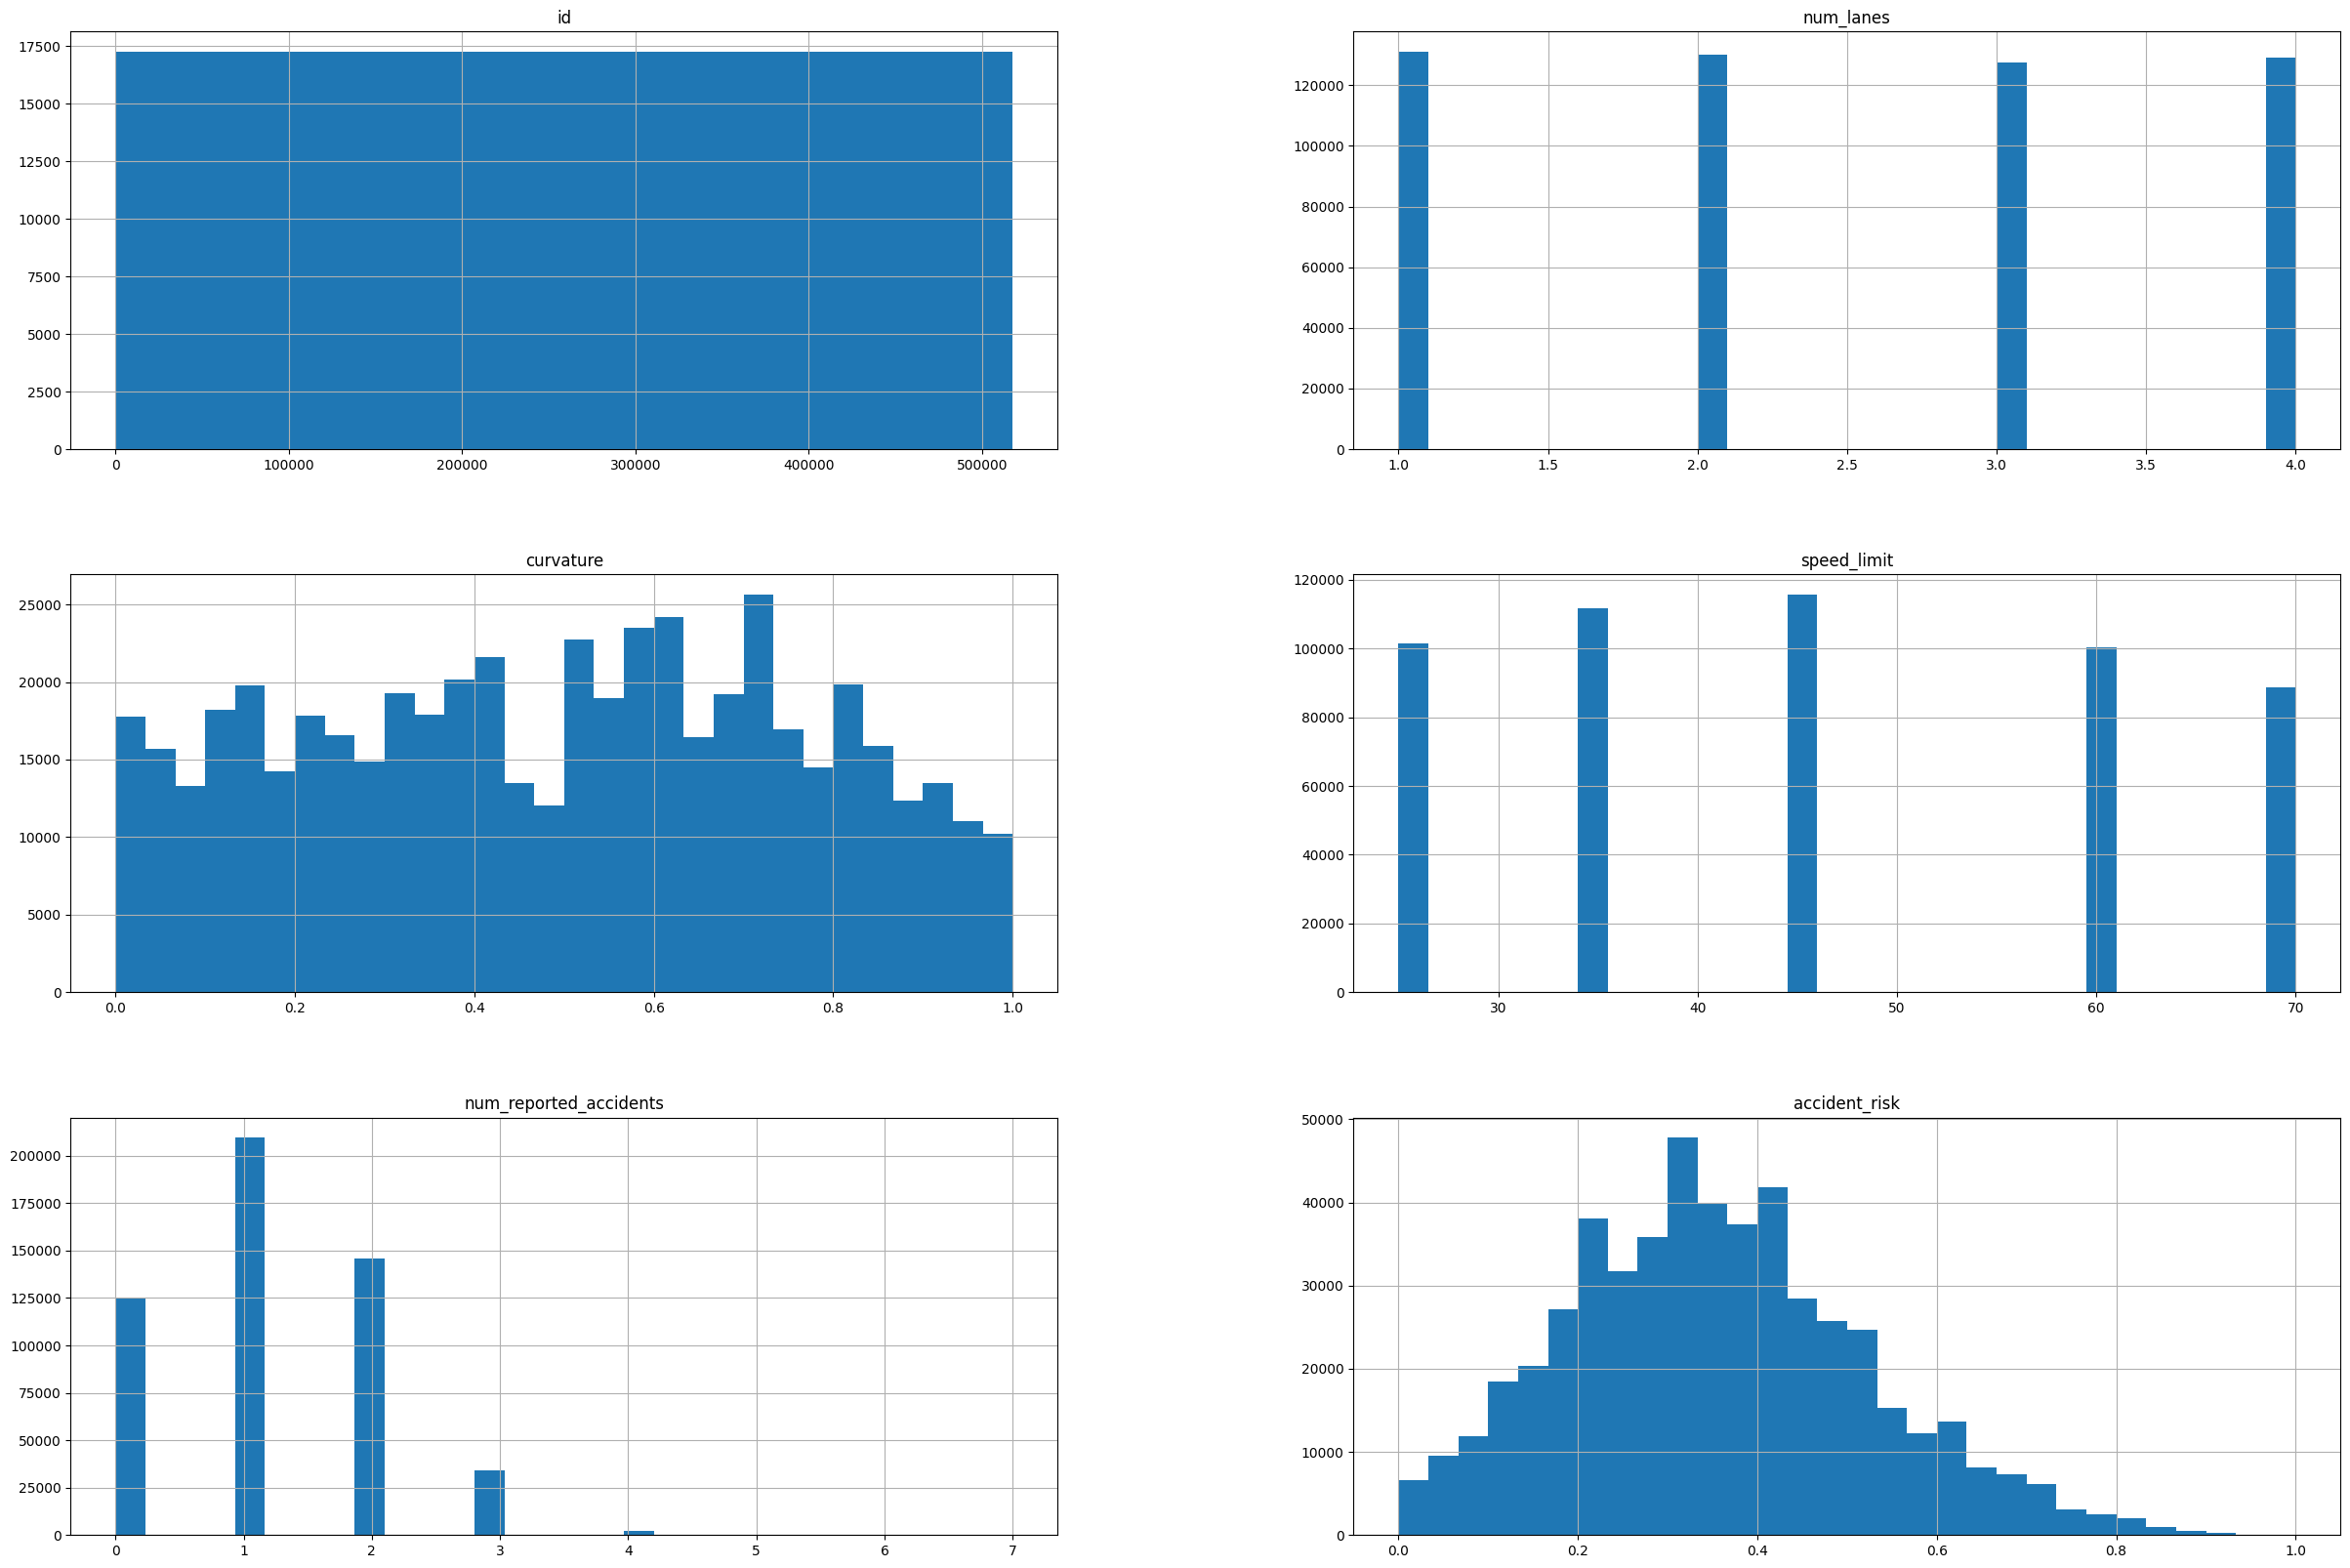

In [7]:
df.hist(bins=30 , figsize=(30,20))

In [8]:
df.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [9]:
df['lighting']

0         daylight
1         daylight
2              dim
3              dim
4         daylight
            ...   
517749    daylight
517750    daylight
517751    daylight
517752       night
517753         dim
Name: lighting, Length: 517754, dtype: object

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([-0.5 , -0.48, -0.46, -0.44, -0.42, -0.4 , -0.38, -0.36, -0.34,
        -0.32, -0.3 , -0.28, -0.26, -0.24, -0.22, -0.2 , -0.18, -0.16,
        -0.14, -0.12, -0.1 , -0.08, -0.06, -0.04, -0.02,  0.  ,  0.02,
         0.04,  0.06,  0.08,  0.1 ,  0.12,  0.14,  0.16,  0.18,  0.2 ,
         0.22,  0.24,  0.26,  0.28,  0.3 ,  0.32,  0.34,  0.36,  0.38,
         0.4 ,  0.42,  0.44,  0.46,  0.48,  0.5 ]),
 <BarContainer object of 50 artists>)

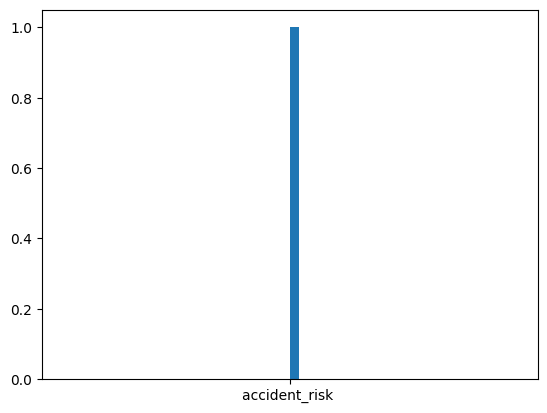

In [10]:
plt.hist('accident_risk ', bins=50)

In [11]:
categorical_cols = ['road_type','lighting' , 'weather' ,'time_of_day' ]

df = pd.get_dummies(df , columns=categorical_cols ,drop_first=1 )

In [12]:
df.head()

,id,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning
0,0,2,0.06,35,False,True,False,True,1,0.13,False,True,False,False,False,True,False,False
1,1,4,0.99,35,True,False,True,True,0,0.35,False,True,False,False,False,False,True,False
2,2,4,0.63,70,False,True,True,False,2,0.30,True,False,True,False,False,False,False,True
3,3,4,0.07,35,True,True,False,False,1,0.21,False,False,True,False,False,True,False,True
4,4,1,0.58,60,False,False,True,False,1,0.56,True,False,False,False,True,False,True,False


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   road_signs_present      517754 non-null  bool   
 5   public_road             517754 non-null  bool   
 6   holiday                 517754 non-null  bool   
 7   school_season           517754 non-null  bool   
 8   num_reported_accidents  517754 non-null  int64  
 9   accident_risk           517754 non-null  float64
 10  road_type_rural         517754 non-null  bool   
 11  road_type_urban         517754 non-null  bool   
 12  lighting_dim            517754 non-null  bool   
 13  lighting_night          517754 non-null  bool   
 14  weather_foggy       

In [14]:
X = df.drop('accident_risk' , axis=True)
Y=df['accident_risk']

In [15]:
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
Y

0         0.13
1         0.35
2         0.30
3         0.21
4         0.56
          ... 
517749    0.32
517750    0.26
517751    0.19
517752    0.51
517753    0.22
Name: accident_risk, Length: 517754, dtype: float64

In [17]:
x_train , x_test , y_train , y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [18]:
scaler=StandardScaler()

In [19]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(x_train_scaled , y_train)

RandomForestRegressor(random_state=42)

In [21]:
y_pred = rf_model.predict(x_test_scaled)

In [22]:
y_pred

array([0.1244, 0.3265, 0.2721, ..., 0.3899, 0.1323, 0.1669])

In [23]:
auc = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(auc)
print(rmse)

0.058207198456206526


In [24]:
df_test = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv')

In [25]:
df_test.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


In [26]:
df_test.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64

In [27]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172585 entries, 0 to 172584
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      172585 non-null  int64  
 1   road_type               172585 non-null  object 
 2   num_lanes               172585 non-null  int64  
 3   curvature               172585 non-null  float64
 4   speed_limit             172585 non-null  int64  
 5   lighting                172585 non-null  object 
 6   weather                 172585 non-null  object 
 7   road_signs_present      172585 non-null  bool   
 8   public_road             172585 non-null  bool   
 9   time_of_day             172585 non-null  object 
 10  holiday                 172585 non-null  bool   
 11  school_season           172585 non-null  bool   
 12  num_reported_accidents  172585 non-null  int64  
dtypes: bool(4), float64(1), int64(4), object(4)
memory usage: 12.5+ MB


In [28]:
cate_col = ['road_type' , 'lighting' , 'weather' , 'time_of_day']

df_test = pd.get_dummies(df_test , columns = cate_col , drop_first=1)


In [29]:
df_test.head()

,id,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning
0,517754,2,0.34,45,True,True,True,True,1,False,False,False,True,False,False,False,False
1,517755,3,0.04,45,True,False,True,False,0,False,True,True,False,True,False,False,False
2,517756,2,0.59,35,True,False,True,True,1,False,True,True,False,False,False,False,False
3,517757,4,0.95,35,False,False,False,False,2,True,False,False,False,False,True,False,False
4,517758,2,0.86,35,True,False,False,True,3,False,False,False,False,False,False,True,False


In [30]:
df_test_scaled = scaler.fit_transform(df_test)


In [31]:
y_test_pred = rf_model.predict(df_test_scaled)


In [32]:
y_test_pred

array([0.2948, 0.1248, 0.1977, ..., 0.2546, 0.0982, 0.4796])

In [33]:
test_ids = df_test['id'].copy()

In [34]:
submission_df = pd.DataFrame({
    'id' : test_ids,
    'accident_risk':y_test_pred
})

In [35]:
submission_df.to_csv('submission.csv', index=False)

In [36]:
s = pd.read_csv('/kaggle/working/submission.csv')
s.head()

,id,accident_risk
0,517754,0.2948
1,517755,0.1248
2,517756,0.1977
3,517757,0.3257
4,517758,0.4148
